# TESTING MODELS

I have trained 2 models; one on the original dataset, and another on the transformed dataset mimicing xrays produced from a different protocol. The underlying xrays are the same, they just differ in noise, blur, intensity, contrast, etc (these are visual differences produced through different xray protocols or different machinery). 

Here I test the models. I test the original model on both the original and transformed dataset, and I repeat this for the transformed model. This gives insight on how different the model performance is, and the dependency on the underlying medical imaging protocol. 

In [15]:
import tensorflow as tf
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report
import matplotlib.pyplot as plt
import pandas as pd

## Importing Datasets and Models

Here I am loading the original and the transformed xray test sets. As explained before, the underlying images are the same (same patient, and structure), but the differences are in 'quality' of the image. I have also imported the models separately. The image preprocessing is the same as the one applied while training the model. 

In [16]:
PATH_TO_OG_DATASET = "../chest_xray/xray_og/original_dataset.csv"
PATH_TO_TRANSFORMED_DATASET = "../chest_xray/xray_transformed/transform_dataset.csv"

OG_MODEL = "models/original_xray.keras"
TRANSFORMED_MODEL = "models/transformed_xray.keras"

In [17]:
def load_image(path, label):    #load image and the label from the csv
    img = tf.io.read_file(path)
    img = tf.image.decode_image(img, channels=3, expand_animations=False)
    img = tf.image.resize(img,(224,224))
    img = img/255.0   #normalise img
    return img, label

def make_dataset(df, shuffle=False):
    paths  = df["path"].values
    labels = df["label"].values.astype("float32")
    ds = tf.data.Dataset.from_tensor_slices((paths, labels))
    if shuffle:
        ds = ds.shuffle(buffer_size=len(df))
    ds = ds.map(load_image, num_parallel_calls=tf.data.AUTOTUNE)
    ds = ds.batch(32)
    ds = ds.prefetch(tf.data.AUTOTUNE)
    return ds

df_og = pd.read_csv(PATH_TO_OG_DATASET)
df_trans = pd.read_csv(PATH_TO_TRANSFORMED_DATASET)

test_og = df_og[df_og["split"] == "test"]
test_trans = df_trans[df_trans["split"] == "test"]

# train, val = train_test_split(total_train, test_size=0.2, random_state=42, stratify=total_train["label"])

print("Original test: ", test_og["label"].value_counts().to_dict())
print("Transformed test: ", test_trans["label"].value_counts().to_dict())


test_ds_og = make_dataset(test_og)
test_ds_trans = make_dataset(test_trans)

Original test:  {1: 390, 0: 234}
Transformed test:  {1: 390, 0: 234}


In [18]:
#importing model
original_model = tf.keras.models.load_model(OG_MODEL)
transformed_model = tf.keras.models.load_model(TRANSFORMED_MODEL)

## Testing Original Model

Here I am testing the performance of the model trained on the original xray dataset. I evaluate it on the test sets from the original and transformed datasets to see difference in performance

### On Original Xray Testset 

20/20 ━━━━━━━━━━━━━━━━━━━━ 2s 54ms/step - accuracy: 0.8766 - auc: 0.8548 - loss: 85.3263 - precision: 0.8717 - recall: 0.9410 
loss: 85.3263
compile_metrics: 0.8766
20/20 ━━━━━━━━━━━━━━━━━━━━ 1s 58ms/step


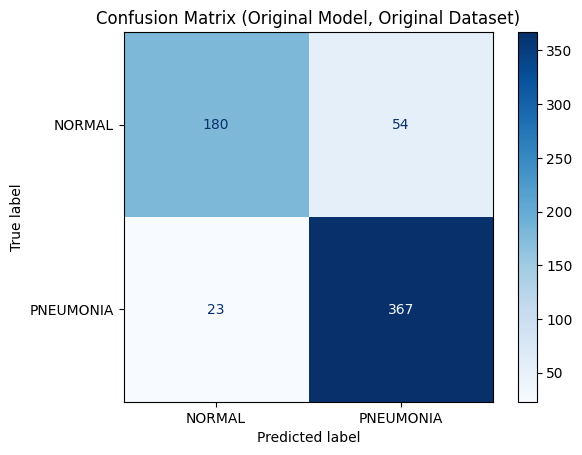

              precision    recall  f1-score   support

      NORMAL       0.89      0.77      0.82       234
   PNEUMONIA       0.87      0.94      0.91       390

    accuracy                           0.88       624
   macro avg       0.88      0.86      0.86       624
weighted avg       0.88      0.88      0.87       624



In [19]:
#run on test set
results_og = original_model.evaluate(test_ds_og)
for name, value in zip(original_model.metrics_names, results_og):
    print(f"{name}: {value:.4f}")

y_true = test_og["label"].values
y_pred = (original_model.predict(test_ds_og) >= 0.5).astype(int).flatten()

cm = confusion_matrix(y_true, y_pred)
disp = ConfusionMatrixDisplay(cm, display_labels=["NORMAL", "PNEUMONIA"])
disp.plot(cmap="Blues")
plt.title("Confusion Matrix (Original Model, Original Dataset)")
plt.show()

print(classification_report(y_true, y_pred, target_names=["NORMAL", "PNEUMONIA"]))

### On Transformed Xray Testset

20/20 ━━━━━━━━━━━━━━━━━━━━ 2s 60ms/step - accuracy: 0.3798 - auc: 0.5038 - loss: 1219.8993 - precision: 1.0000 - recall: 0.0077       
loss: 1219.8993
compile_metrics: 0.3798
20/20 ━━━━━━━━━━━━━━━━━━━━ 1s 43ms/step


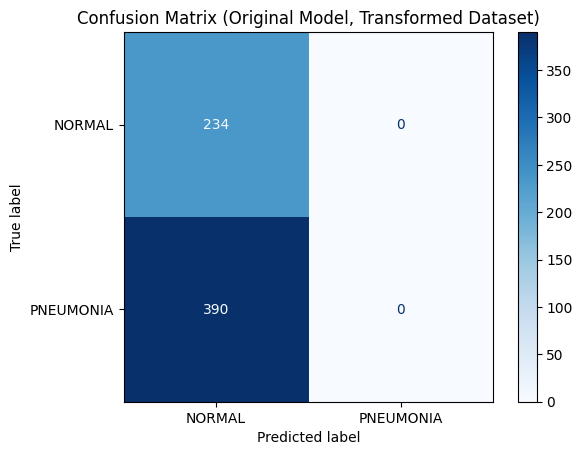

              precision    recall  f1-score   support

      NORMAL       0.38      1.00      0.55       234
   PNEUMONIA       0.00      0.00      0.00       390

    accuracy                           0.38       624
   macro avg       0.19      0.50      0.27       624
weighted avg       0.14      0.38      0.20       624



/Users/zubair/Desktop/ada_final_project/.venv/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/Users/zubair/Desktop/ada_final_project/.venv/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/Users/zubair/Desktop/ada_final_project/.venv/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_p

In [20]:
#run on test set
results_t = original_model.evaluate(test_ds_trans)
for name, value in zip(original_model.metrics_names, results_t):
    print(f"{name}: {value:.4f}")

y_true = test_trans["label"].values
y_pred = (original_model.predict(test_ds_trans) >= 0.5).astype(int).flatten()

cm = confusion_matrix(y_true, y_pred)
disp = ConfusionMatrixDisplay(cm, display_labels=["NORMAL", "PNEUMONIA"])
disp.plot(cmap="Blues")
plt.title("Confusion Matrix (Original Model, Transformed Dataset)")
plt.show()

print(classification_report(y_true, y_pred, target_names=["NORMAL", "PNEUMONIA"]))

## Testing Transformed Model

Here I am testing the performance of the model trained on the transformed xray dataset. I evaluate it on the test sets from the original and transformed datasets to see difference in performance

### On Original Xray Testset

20/20 ━━━━━━━━━━━━━━━━━━━━ 2s 54ms/step - accuracy: 0.5913 - auc: 0.6585 - loss: 247.4005 - precision: 0.8994 - recall: 0.3897 
loss: 247.4005
compile_metrics: 0.5913
20/20 ━━━━━━━━━━━━━━━━━━━━ 2s 56ms/step


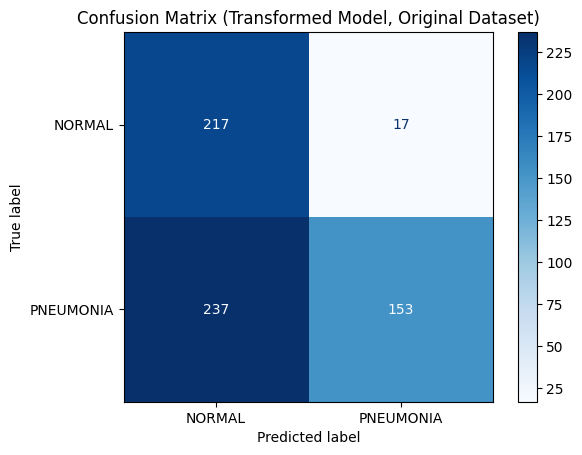

              precision    recall  f1-score   support

      NORMAL       0.48      0.93      0.63       234
   PNEUMONIA       0.90      0.39      0.55       390

    accuracy                           0.59       624
   macro avg       0.69      0.66      0.59       624
weighted avg       0.74      0.59      0.58       624



In [21]:
#run on test set
results_og = transformed_model.evaluate(test_ds_og)
for name, value in zip(transformed_model.metrics_names, results_og):
    print(f"{name}: {value:.4f}")

y_true = test_og["label"].values
y_pred = (transformed_model.predict(test_ds_og) >= 0.5).astype(int).flatten()

cm = confusion_matrix(y_true, y_pred)
disp = ConfusionMatrixDisplay(cm, display_labels=["NORMAL", "PNEUMONIA"])
disp.plot(cmap="Blues")
plt.title("Confusion Matrix (Transformed Model, Original Dataset)")
plt.show()

print(classification_report(y_true, y_pred, target_names=["NORMAL", "PNEUMONIA"]))

### On Transformed Xray Testset

20/20 ━━━━━━━━━━━━━━━━━━━━ 1s 54ms/step - accuracy: 0.8173 - auc: 0.7761 - loss: 137.7788 - precision: 0.8013 - recall: 0.9410
loss: 137.7788
compile_metrics: 0.8173
20/20 ━━━━━━━━━━━━━━━━━━━━ 1s 50ms/step


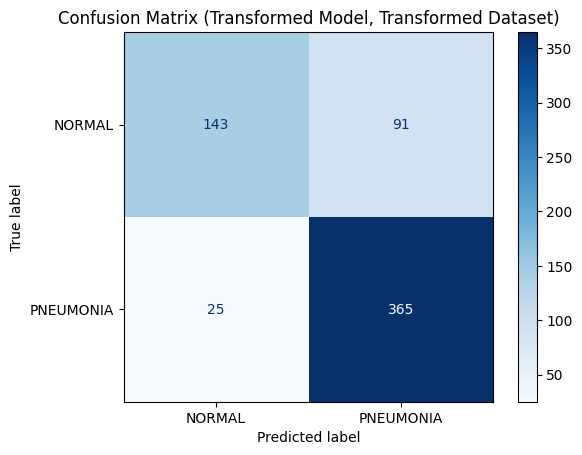

              precision    recall  f1-score   support

      NORMAL       0.85      0.61      0.71       234
   PNEUMONIA       0.80      0.94      0.86       390

    accuracy                           0.81       624
   macro avg       0.83      0.77      0.79       624
weighted avg       0.82      0.81      0.81       624



In [22]:
#run on test set
results_t = transformed_model.evaluate(test_ds_trans)
for name, value in zip(transformed_model.metrics_names, results_t):
    print(f"{name}: {value:.4f}")

y_true = test_trans["label"].values
y_pred = (transformed_model.predict(test_ds_trans) >= 0.5).astype(int).flatten()

cm = confusion_matrix(y_true, y_pred)
disp = ConfusionMatrixDisplay(cm, display_labels=["NORMAL", "PNEUMONIA"])
disp.plot(cmap="Blues")
plt.title("Confusion Matrix (Transformed Model, Transformed Dataset)")
plt.show()

print(classification_report(y_true, y_pred, target_names=["NORMAL", "PNEUMONIA"]))

## General Analysis

Before going into the analysis part, I want to show a sample of the original Xray along with the transformed one to show what the difference is

<table>
  <tr>
    <td align="center">
      <b>Original Xray</b><br>
      <img src="../chest_xray/xray_og/test/NORMAL/IM-0001-0001.jpeg" width="400"/>
    </td>
    <td align="center">
      <b>Transformed Xray</b><br>
      <img src="../chest_xray/xray_transformed/test/NORMAL/IM-0001-0001.jpeg" width="400"/>
    </td>
  </tr>
</table>

The difference isn't immediately apparent, but you can notice that in the transformed version the image is a bit more blury, the contrast is different, and the visibility of fine grained features (edges of the ribcage) is different. 

On training a model on the original dataset, the performance drops drastically when running on the transformed dataset. The model just labels everything as normal, with no accurate classification of cases with Pneumonia. The model trained on the transformed data, although poor, still does better on the original dataset (the data it is not trained on); and performs well on the transformed dataset as expected. 

It's important to note that the dataset is the same, the visual quality is the only thing changed; so, the underlying structures are identical, the assumed signs for pneumonia or not are exactly the same, just the resolution, noise, etc is different. 

Based on this, without further analysis we can note that the model trained on poorer quality data still performs well on higher quality data; we could say it is more robust. However, the model trained on higher quality data completely collapses when dealing with poorer quality data. So before getting deeper into the analysis, we can assume that there is a high dependence on the radiology protocol and machinery as it influences the image quality. 

In the next checkpoint, I want to analyse the results further, go into more detail and also train another model on a combination of original and transformed data and compare its performance to see if combining data from various protocols can help model performance.
